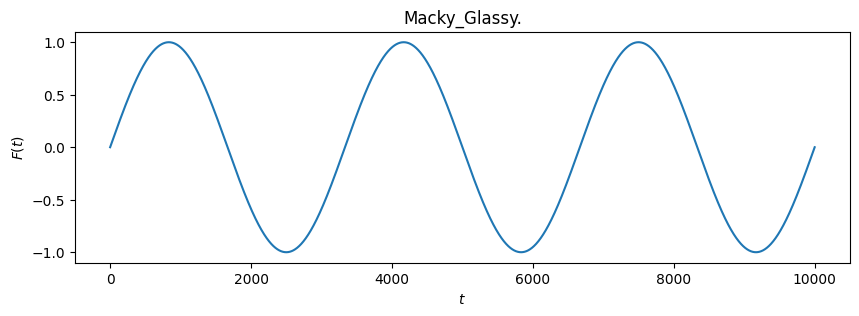

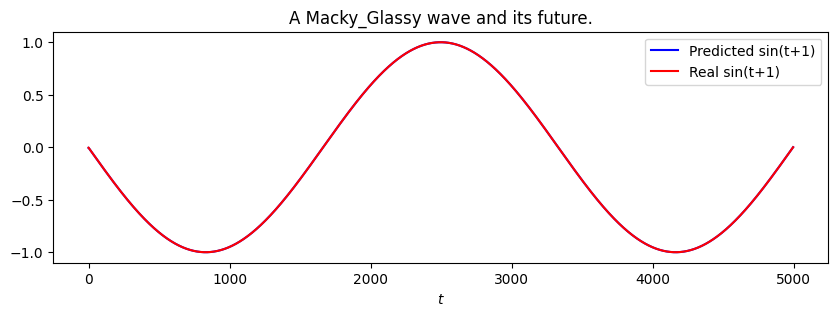

RMSE: 2.3062465907958647e-05 R^2 score: 0.9999999988312742 mse 5.318773337557549e-10 nrmse 1.1531232161759586e-05
Input int quantized:
 [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] 

Input scale: 0.0078125
Input zero_point: 0.0
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
int8
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] /n


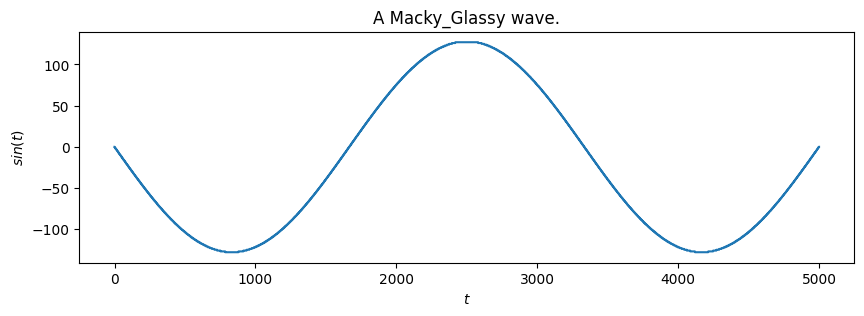

Extract quantized integer Win and Scale and Zero_point
Input int quantized:
 [[-128]
 [ 127]
 [   0]
 [ 127]
 [-128]
 [-128]
 [-128]
 [ 127]
 [-128]
 [ 127]
 [-128]
 [   0]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [   0]
 [ 127]
 [-128]
 [   0]
 [-128]
 [-128]
 [   0]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [ 127]
 [ 127]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [   0]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [   0]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [   0]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [   0]
 [-128]
 [-128]
 [-128]
 [   0]
 [-128]
 [-128]
 [ 127]
 [-128]
 [ 127]
 [ 127]
 [ 127]
 [-128]
 [   0]
 [ 127]
 [-128]
 [   0]
 [-128]
 [-128]
 [-128]
 [ 127]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [-128]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [-128]
 [ 127]
 [-128]
 [   0]
 [ 127]
 [ 127]
 [ 127]
 [ 127]
 [   0]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-

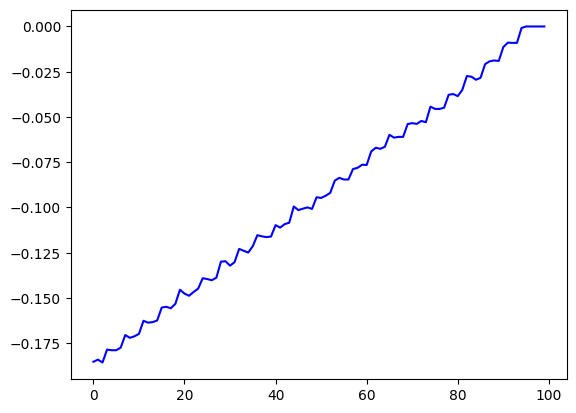

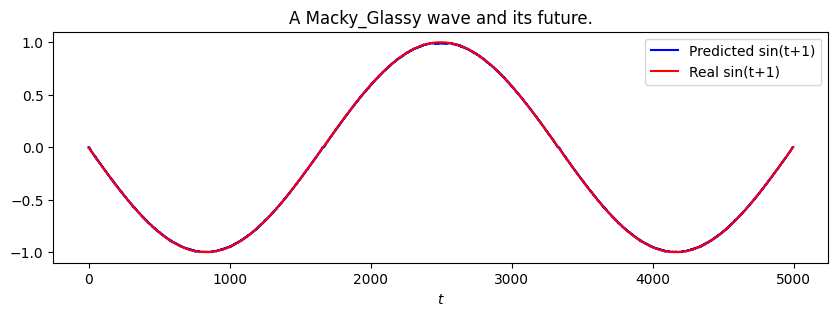

In [11]:
# -*- coding: utf-8 -*-
"""Glassy.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1YZAeCPgA-ehOwhu4TSqFB8sigUrGjG4m
"""

# -*- coding: utf-8 -*-
"""V.3 of final_version_Multi_Threshold_and_Absobing.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/16HNHfBAcu6nQccaECqvTNhPSyuoIcJ4s
"""

#pip install hyperopt jupyter matplotlib pandas requests reservoirpy scikit-learn seaborn brevitas fxpmath

import numpy as np
import torch

from brevitas.nn import QuantIdentity
import math
from reservoirpy.observables import rmse, rsquare,mse,nrmse
import numpy as np

from reservoirpy import Node
from brevitas.nn import QuantHardTanh

from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math
from reservoirpy.datasets import mackey_glass

import numpy as np
import matplotlib.pyplot as plt
from fxpmath import Fxp
from reservoirpy.nodes import Reservoir, Ridge

def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point

# output weight


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale
  # return out,scale,zero_point


# X = np.sin(np.linspace(0, 6*np.pi, 10000)).reshape(-1, 1)

# plt.figure(figsize=(10, 3))
# plt.title("A Macky_Glassy wave.")
# plt.ylabel("$sin(t)$")
# plt.xlabel("$t$")
# plt.plot(X)
# plt.show()

# X_train = X[:5000]
# Y_train = X[1:5001]

# plt.figure(figsize=(10, 3))
# plt.title("A Macky_Glassy wave and its future.")
# plt.xlabel("$t$")
# plt.plot(X_train, label="sin(t)", color="blue")
# plt.plot(Y_train, label="sin(t+1)", color="red")
# plt.legend()
# plt.show()Macky_Glassy
import reservoirpy as rpy
rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!

X = np.sin(np.linspace(0, 6*np.pi, 10000)).reshape(-1, 1)
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1
# create fxp variable with value 7.25

#reservoir = Reservoir(units=400, lr=0.1, sr=1.25)
N=149
#reservoir = Reservoir(10, lr=1, sr=1.25, input_connectivity=0.90,rc_connectivity=0.1,input_scaling=0.001)
reservoir = Reservoir(N, lr=1, sr=0.9, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=1)

readout = Ridge(output_dim=1, ridge=1e-8)
esn_model = reservoir >> readout
esn_model=esn_model.fit(X[:5000], X[1:5001], warmup=100)


plt.figure(figsize=(10, 3))
plt.title("Macky_Glassy.")
plt.ylabel("$F(t)$")
plt.xlabel("$t$")
plt.plot(X)
plt.show()


#reservoir = Reservoir(200, lr=0.02, sr=0.1, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=1)
# reservoir = Reservoir(10, lr=1, sr=0.9, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=1)
# readout = Ridge(ridge=1e-15)

# esn_model = reservoir >> readout

# esn_model = esn_model.fit(X_train, Y_train, warmup=400)

# print('Extract quantized integer input and Scale and Zero_point')
# extract_Qinput(X_test)

Y_pred = esn_model.run(X[5001:-1])

plt.figure(figsize=(10, 3))
plt.title("A Macky_Glassy wave and its future.")
plt.xlabel("$t$")
plt.plot(Y_pred, label="Predicted sin(t+1)", color="blue")
plt.plot(X[5002:].astype(float), label="Real sin(t+1)", color="red")
plt.legend()
plt.show()

readout.ridge
print("RMSE:", rmse(Y_pred, X[5002:]), "R^2 score:", rsquare(Y_pred, X[5002:]),"mse" ,mse(Y_pred, X[5002:]),"nrmse",nrmse(Y_pred, X[5002:]))

############## Qunatize inputs

int_x,x_scale,x_zero_point = extract_Qinput(X)
print(int_x)
np.savetxt('input_data1.txt', int_x, fmt='%s', delimiter=',')
# #x = np.reshape(x,(10000,1))

#np.savetxt('input_data.csv',x[5002:](), fmt='%b', delimiter=',')
#np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print(int_x.dtype)
print(int_x,"/n")

plt.figure(figsize=(10, 3))
plt.title("A Macky_Glassy wave.")
plt.ylabel("$sin(t)$")
plt.xlabel("$t$")
#plt.plot(int_x*x_scale)
plt.plot(int_x[5000:])
plt.show()
# Qauntize Win
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(reservoir.Win.todense())



# Qauntize Wr
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(reservoir.W.todense())
# print('Extract quantized integer bias and Scale and Zero_point')
# int_bias,scale_bias,zero_point_bias = extract_Qweights(reservoir.bias.data)

reservoir.state()

input_scale = (scale_Win * x_scale)

threshold_scale = 0.0078125

reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    return (x / 256).astype(np.int32)



a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)


"""# **Newly added codes**"""

readout.Wout

#Multi Threshold
state_int, state_scale, state_zero_point=extract_Qinput(reservoir.state())


from reservoirpy import Node
def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int32)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias

    r = state_int @ W_res
    s = W_in.astype(np.int32) @ x
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)

    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", reservoir.bias.todense())

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")

esn_model2 = node >> readout

# readout.set_param("ridge",1e-6)

"""# **End of newly added codes**"""

esn_model2 = esn_model2.fit(int_x[:5000].astype(np.float64), int_x[1:5001], warmup=400)

state2=node.state()
bias=node.Bias
readout.Wout
bit_width=8
Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
readout.Wout = Wout_quantized
print(scale_out)

readout.Wout

scale_out_bin = Fxp(scale_out, True,32,31)
print(scale_out)
print(scale_out_bin.bin())

a=threshold_scale * scale_out
print("scaleee",a)

node.state()

Y_pred2 = esn_model2.run(int_x[5001:-1])
#print(predictions2)

Y_pred2
Y_pred2 = Y_pred2 *a
print("RMSE:", rmse(Y_pred, Y_pred2), "R^2 score:", rsquare(Y_pred, Y_pred2),"mse" ,mse(Y_pred, Y_pred2),"nrmse",nrmse(Y_pred, Y_pred2))



#plt.plot(Y_pred2, label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred2[-100:], label="Predicted sin(t+1)", color="blue")

#Y_pred = esn_model.run(X[50:len(X)-1])

plt.figure(figsize=(10, 3))
plt.title("A Macky_Glassy wave and its future.")
plt.xlabel("$t$")
plt.plot(Y_pred2, label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred, label="Real sin(t+1)", color="red")
plt.legend()
plt.show()
np.savetxt(f"Y_pred2_49.txt", Y_pred2)
fwoutindex = open('scale_49.txt', 'w')
print("%.25f,"%a, file=fwoutindex)

In [12]:
import sin


def generate_verilog_code(num_reservoir_neurons, input_weight, reservoir_state, a_scaled, b_scaled, c_scaled, d_scaled, reservoir_weight, output_weight):
    code = f"""`timescale 1ns / 1ps
//////////////////////////////////////////////////////////////////////////////////
// Company:
// Engineer:
//
// Create Date: 03/04/2024 09:10:17 AM
// Design Name:
// Module Name: EchoStateNetwork
// Project Name:
// Target Devices:
// Tool Versions:
// Description:
//
// Dependencies:
//
// Revision:
// Revision 0.01 - File Created
// Additional Comments:
//
//////////////////////////////////////////////////////////////////////////////////

module ESN_Generator_V2(
    input clk,
    input signed [7:0] input_data,     // Q2.6 format
    output wire signed [31:0] output_data   // Q2.6 format
);
parameter num_reservoir_neurons = {num_reservoir_neurons};

// Reservoir layer
reg signed [15:0] a_scaled = 16'd{a_scaled};
reg signed [15:0] b_scaled = 16'd{b_scaled};
reg signed [15:0] c_scaled = 16'd{c_scaled};
reg signed [15:0] d_scaled = 16'd{d_scaled};
reg signed [15:0] reservoir_state [0: num_reservoir_neurons-1]; // Q4.12 format
initial begin
"""
    for i in range(num_reservoir_neurons):
        if i < num_reservoir_neurons - 1:
            if reservoir_state[0][i]<0:
                code += f"reservoir_state[{i}] = -16'sd{abs(reservoir_state[0][i])};\n"
            else:
                 code += f"reservoir_state[{i}] = 16'sd{reservoir_state[0][i]};\n"
        else:
            if reservoir_state[0][i]<0:
                code += f"reservoir_state[{i}] = -16'sd{abs(reservoir_state[0][i])};\n"
            else:
                code += f"reservoir_state[{i}] = 16'sd{abs(reservoir_state[0][i])};\n"

    code += """end

  // Scaling factors and zero point
  reg signed [31:0] scale = 32'b00000000000001011001011001000000;         // Q2.14 format

  reg signed [31:0] input_sum_parallel [0: num_reservoir_neurons-1];
  reg signed [31:0] reservoir_sum_parallel [0: num_reservoir_neurons-1];
  reg signed [31:0] output_sum;
  integer i,j,k,l,m;

  reg signed [31:0] reg_input [0: num_reservoir_neurons-1];
  reg signed [31:0] reg_reservoir [0: num_reservoir_neurons-1];
"""
    # for i in range(8):
    #     if i < 7:
    #         code += f"reg signed [31:0] shifted_input{i};\n"
    #     else:
    #         code += f"reg signed [31:0] shifted_input{i};\n"


    for i in range(num_reservoir_neurons):
        for j in range(num_reservoir_neurons):

            for bit in range(8):
                if (reservoir_weight[j][i] >> bit) & 1:
                    code += f"wire signed [31:0] shifted_state{i}_{j}_{bit} = reservoir_state[{j}] <<< {bit};\n"

    for i in range(num_reservoir_neurons):
        for bit in range(8):
            if (output_weight[i] >> bit) & 1:
                code += f"wire signed [31:0] shifted_state_out{i}_{bit} = reservoir_state[{i}] <<< {bit};\n"


    for i in range(8):
        if i < 7:
            code += f"wire signed [31:0] shifted_input{i} = input_data <<< {i};\n"
        else:
            code += f"wire signed [31:0] shifted_input{i} = input_data <<< {i};\n"

    code +="""
  // ESN logic
  always @(posedge clk) begin

"""



    for i in range(num_reservoir_neurons):
        input_mults = []
        for bit in range(8):
            if (input_weight[i] >> bit) & 1:
                input_mults.append(f"shifted_input{bit}")
        if input_mults:
          code += f"      input_sum_parallel[{i}] = " + " + ".join(input_mults) + ";\n"
        else:
          code += f"      input_sum_parallel[{i}] = 0" + ";\n"

    for i in range(num_reservoir_neurons):
        if i < num_reservoir_neurons-1:
            code += f"reservoir_sum_parallel[{i}] = 32'sd0;\n"
        else:
            code += f"reservoir_sum_parallel[{i}] = 32'sd0;\n"


    for i in range(num_reservoir_neurons):
        # code += f"      reservoir_sum_parallel[{i}] = 0;\n"
        reservoir_weight_mults = []
        for j in range(num_reservoir_neurons):

            for bit in range(8):
                if (reservoir_weight[j][i] >> bit) & 1:
                    reservoir_weight_mults.append(f"shifted_state{i}_{j}_{bit}")
        if reservoir_weight_mults:
          code += f"      reservoir_sum_parallel[{i}] = (" + " + ".join(reservoir_weight_mults) + ");\n"
        else:
          code += f"      reservoir_sum_parallel[{i}] = 0" + ";\n"

    code += """      // Threshold comparisons
      for (i = 0; i < num_reservoir_neurons; i = i + 1) begin
          reg_input[i] = 0;
          if (input_sum_parallel[i] < a_scaled) begin
              reg_input[i] = a_scaled;
         end
          else if (input_sum_parallel[i] > b_scaled) begin
              reg_input[i] = b_scaled;
          end
          else begin
              reg_input[i] = input_sum_parallel[i];
          end
      end

      for (k = 0; k < num_reservoir_neurons; k = k + 1) begin
          reg_reservoir[k] = 0;
          if (reservoir_sum_parallel[k] < c_scaled) begin
              reg_reservoir[i] = c_scaled;
          end
          else if (reservoir_sum_parallel[k] > d_scaled) begin
              reg_reservoir[k] = d_scaled;
          end
          else begin
              reg_reservoir[k] = reservoir_sum_parallel[k];
          end
      end


      for (j = 0; j < num_reservoir_neurons; j = j + 1) begin
      reg_input[j]=reg_input[j]+16'd1628;

          reg_input[j] = reg_input[j] >> 8;
          reg_reservoir[j]=reg_reservoir[j]+16'd17641;
          reg_reservoir[j]= reg_reservoir[j] >> 8;
      end

  // Store results in reservoir_states
      for (m = 0; m < num_reservoir_neurons; m = m + 1) begin
          reservoir_state[m] <= reg_reservoir[m] + reg_input[m]-255;
      end
"""

    code += """      // Output calculation
      output_sum = 0;
"""
    out_weight_mults = []
    for i in range(num_reservoir_neurons):

        for bit in range(8):
            if (output_weight[i] >> bit) & 1:
                out_weight_mults.append(f"shifted_state_out{i}_{bit}")
    code += f"      output_sum = output_sum + (" + " + ".join(out_weight_mults) + ");\n"

    code += """
    end
    assign output_data = output_sum;
endmodule
"""
    return code





verilog_code= generate_verilog_code(N, int_Win,state_int,a_scaled, b_scaled,c_scaled,d_scaled, int_Wr, Wout_quantized)
with open("compressed_size1.v", "w") as verilog_file:
    verilog_file.write(verilog_code)
